# TMDB - Box Office Prediction

Table of Contents

- [1. Data Loading and Overview](#1-data-loading-and-overview)
  - [1.1 Dictionaries Extraction](#11-dictionaries-extraction)
  - [1.2 Release Dates Parsing](#12-release-dates-parsing)

- [2. EDA - Exploratory Data Analysis](#2-eda---exploratory-data-analysis)
  - [2.1 Revenue](#21-revenue)
  - [2.2 Release Date](#22-release-date)
  - [2.3 Budget](#23-budget)
  - [2.4 Genres](#24-genres)
  - [2.5 Homepage](#25-homepage)
  - [2.6 Original Language](#26-original-language)
  - [2.7 Production Companies](#27-production-companies)
  - [2.8 Production Countries](#28-production-countries)
  - [2.9 Spoken Languages](#29-spoken-languages)
  - [2.10 Tagline](#210-tagline)
  - [2.11 Keywords](#211-keywords)
  - [2.12 Cast](#212-cast)
  - [2.13 Crew](#213-crew)
  - [2.14 Popularity](#214-popularity)
  - [2.15 Belongs To Collection](#215-belongs-to-collection)

- [3. Feature Engineering](#3-feature-engineering)
  - [3.1 Release Date](#31-release-date)
  - [3.2 Belongs To Collection](#32-belongs-to-collection)
  - [3.3 Budget](#33-budget)
  - [3.4 Genres](#34-genres)
  - [3.5 Homepage](#35-homepage)
  - [3.6 Original Language](#36-original-language)
  - [3.7 Production Companies](#37-production-companies)
  - [3.8 Production Countries](#38-production-countries)
  - [3.9 Spoken Languages](#39-spoken-languages)
  - [3.10 Tagline](#310-tagline)
  - [3.11 Keywords](#311-keywords)
  - [3.12 Cast](#312-cast)
  - [3.13 Crew](#313-crew)
  - [3.14 Popularity](#314-popularity)
  - [3.15 Runtime](#315-runtime)
  - [3.16 Cross Features](#316-cross-features)
  - [3.17 Other Features](#317-other-features)
  - [3.18 Preprocessing Pipeline](#318-preprocessing-pipeline)

- [4. Model Tuning](#4-model-tuning)
  - [4.1 Random Forest](#41-random-forest-regressor)
  - [4.2 XGBoost](#42-xgboost-regressor)
  - [4.3 Results](#43-results)

- [5. Prediction and Submission](#5-prediction-and-submission)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_log_error
from wordcloud import WordCloud
import ast

%matplotlib inline
random_state = 42
test_size = 0.2
np.random.seed(random_state)

## 1. Data Loading and Overview

In [2]:
train = pd.read_csv('../data/train.csv', index_col='id')
test = pd.read_csv('../data/test.csv', index_col='id')

print(f"Shape of the train set: {train.shape}")
print(f"Shape of the test set: {test.shape}")

Shape of the train set: (3000, 22)
Shape of the test set: (4398, 21)


In [3]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 1 to 3000
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   belongs_to_collection  604 non-null    str    
 1   budget                 3000 non-null   int64  
 2   genres                 2993 non-null   str    
 3   homepage               946 non-null    str    
 4   imdb_id                3000 non-null   str    
 5   original_language      3000 non-null   str    
 6   original_title         3000 non-null   str    
 7   overview               2992 non-null   str    
 8   popularity             3000 non-null   float64
 9   poster_path            2999 non-null   str    
 10  production_companies   2844 non-null   str    
 11  production_countries   2945 non-null   str    
 12  release_date           3000 non-null   str    
 13  runtime                2998 non-null   float64
 14  spoken_languages       2980 non-null   str    
 15  status         

As we can see, there are many columns with null values and some of them are of type object, which means they contain text data. We will need to handle these null values and possibly extract features from the text data later on.

In [4]:
display(train.head())

,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
id,,,,,,,,,,,,,,,,,,,,,
1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


As we can see, there are some columns that contain lists of dictionaries, so we'll need to extract the needed information from those ones.

### 1.1 Dictionaries Extraction

In [5]:
def parse_json(x):
    if pd.isna(x) or x == '':
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return ast.literal_eval(x)
    return []

def extract_from_json(df, column, key):
    return df[column].apply(
        lambda x: [d[key] for d in parse_json(x) if isinstance(d, dict) and key in d]
    )

def extract_role_from_crew(df, role):
    temp = df.copy()
    return temp['crew'].apply(
        lambda x: next(
            (m['name'] for m in ast.literal_eval(x) if m.get('job') == role),
            None
        ) if pd.notna(x) else None
    )

def extract_dictionaries(df):
    temp = df.copy()

    temp['belongs_to_collection'] = extract_from_json(temp, 'belongs_to_collection', 'name')
    temp['genres'] = extract_from_json(temp, 'genres', 'name')
    temp['production_companies'] = extract_from_json(temp, 'production_companies', 'name')
    temp['production_countries'] = extract_from_json(temp, 'production_countries', 'name')
    temp['spoken_languages'] = extract_from_json(temp, 'spoken_languages', 'iso_639_1')
    temp['Keywords'] = extract_from_json(temp, 'Keywords', 'name')
    temp['cast'] = extract_from_json(temp, 'cast', 'name')

    # Crew column contains different roles, we will extract only directors
    temp['director'] = extract_role_from_crew(temp, 'Director')
    temp['crew'] = extract_from_json(temp, 'crew', 'name')

    return temp

train = extract_dictionaries(train)
test = extract_dictionaries(test)


### 1.2 Release Dates Parsing

The Release Dates are in the mm/dd/yy format, but the dataset contains both movies released before and after 2000. That said, we'll convert the dates into mm/dd/yyyy format, to handle better the release years. Note that the competition started in 2019, so we can consider that there are no movies released later than this year.

In [6]:
def parse_release_dates(df):
    df = df.copy()
    df['release_date'] = pd.to_datetime(
        df['release_date'],
        format='%m/%d/%y'
    )

    df.loc[df['release_date'].dt.year > 2019, 'release_date'] -= pd.DateOffset(years=100)

    return df

train = parse_release_dates(train)

# There is a single movie without release date in the test set, so we will fill it with the release date found on https://www.imdb.com/it/title/tt0210130/
test.loc[3829, 'release_date'] = '03/20/01'

test = parse_release_dates(test)

## 2. EDA - Exploratory Data Analysis

### 2.1 Revenue

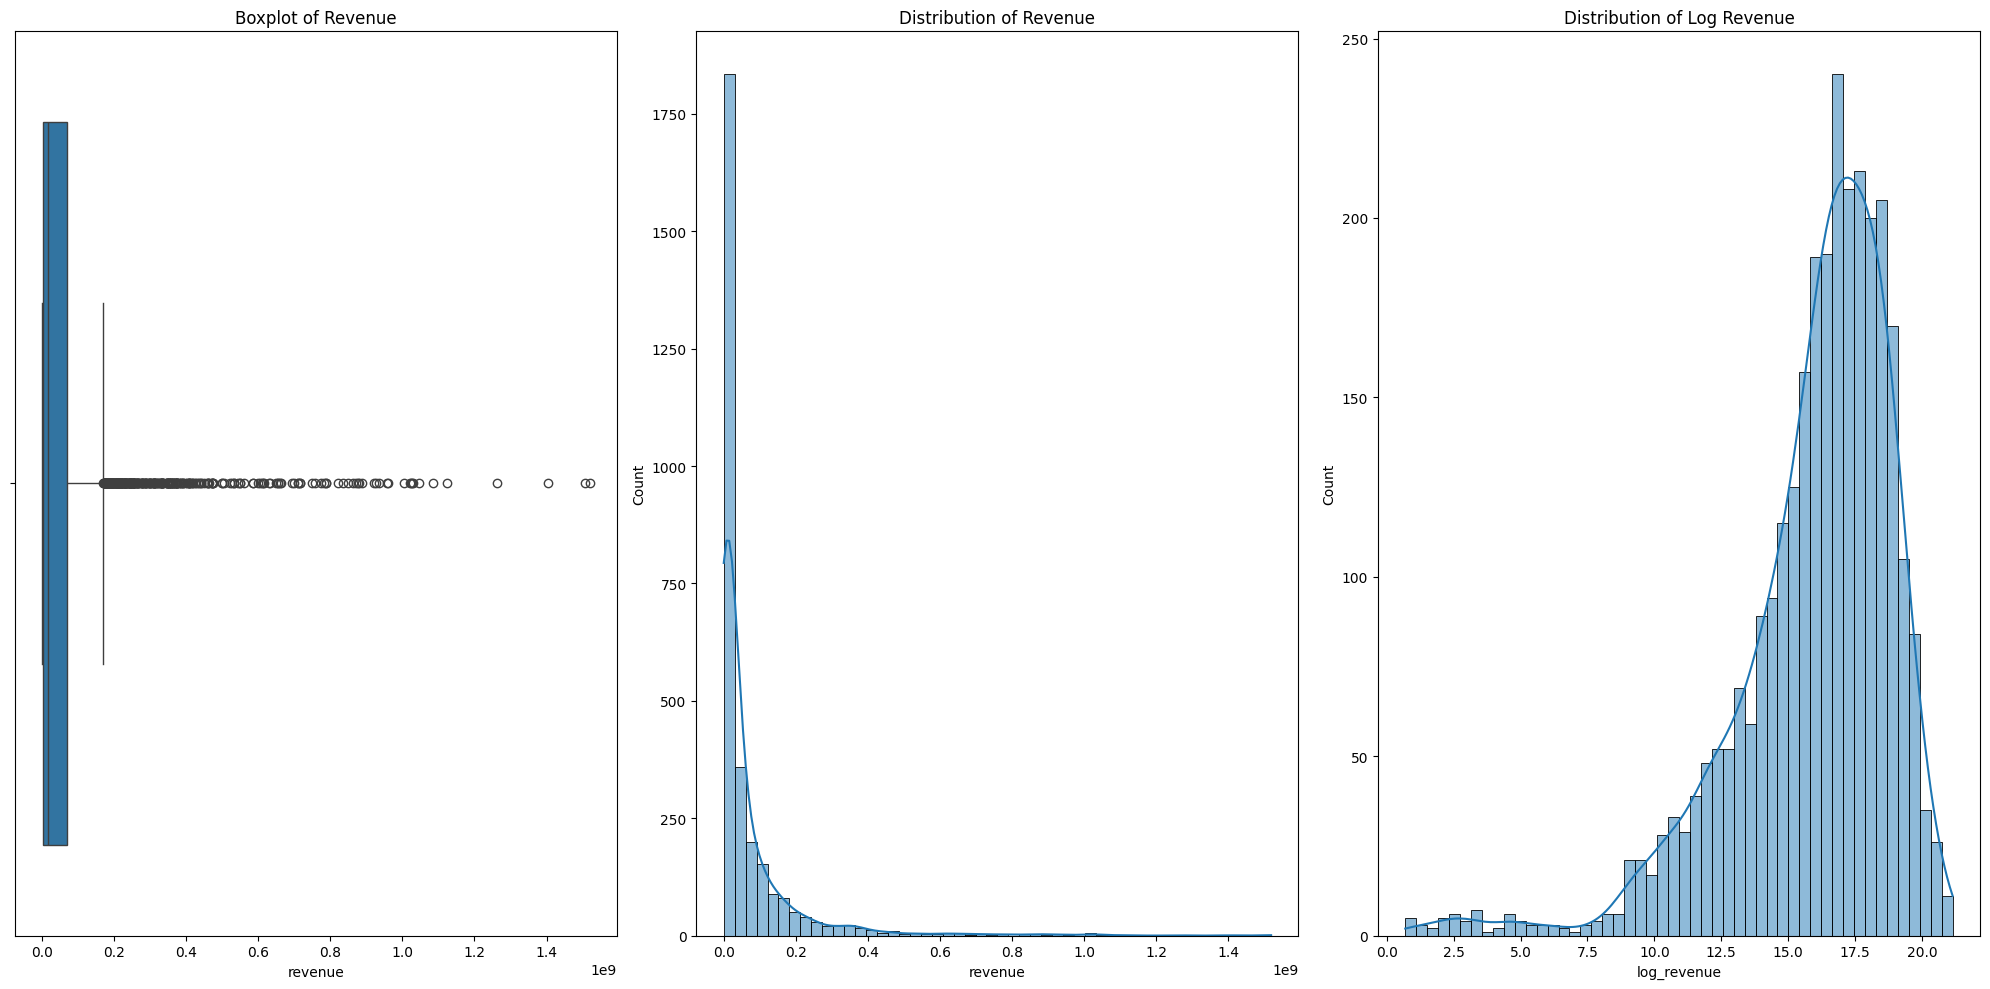

In [7]:
train['log_revenue'] = np.log1p(train['revenue'])

# Plots of the revenue distribution
plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
sns.boxplot(x=train['revenue'])
plt.title('Boxplot of Revenue')
plt.subplot(1, 3, 2)
sns.histplot(train['revenue'], bins=50, kde=True)
plt.title('Distribution of Revenue')
plt.subplot(1, 3, 3)
sns.histplot(train['log_revenue'], bins=50, kde=True)
plt.title('Distribution of Log Revenue')
plt.tight_layout()
plt.show()

The boxplot of revenue shows that there are some outliers in the data, which is expected in a dataset like this. The histogram of revenue is right-skewed, indicating that most movies have low revenue, while a few have very high revenue. The histogram of log revenue is more normally distributed, which suggests that applying a log transformation to the target variable may help improve the performance of our models.

### 2.2 Release Date

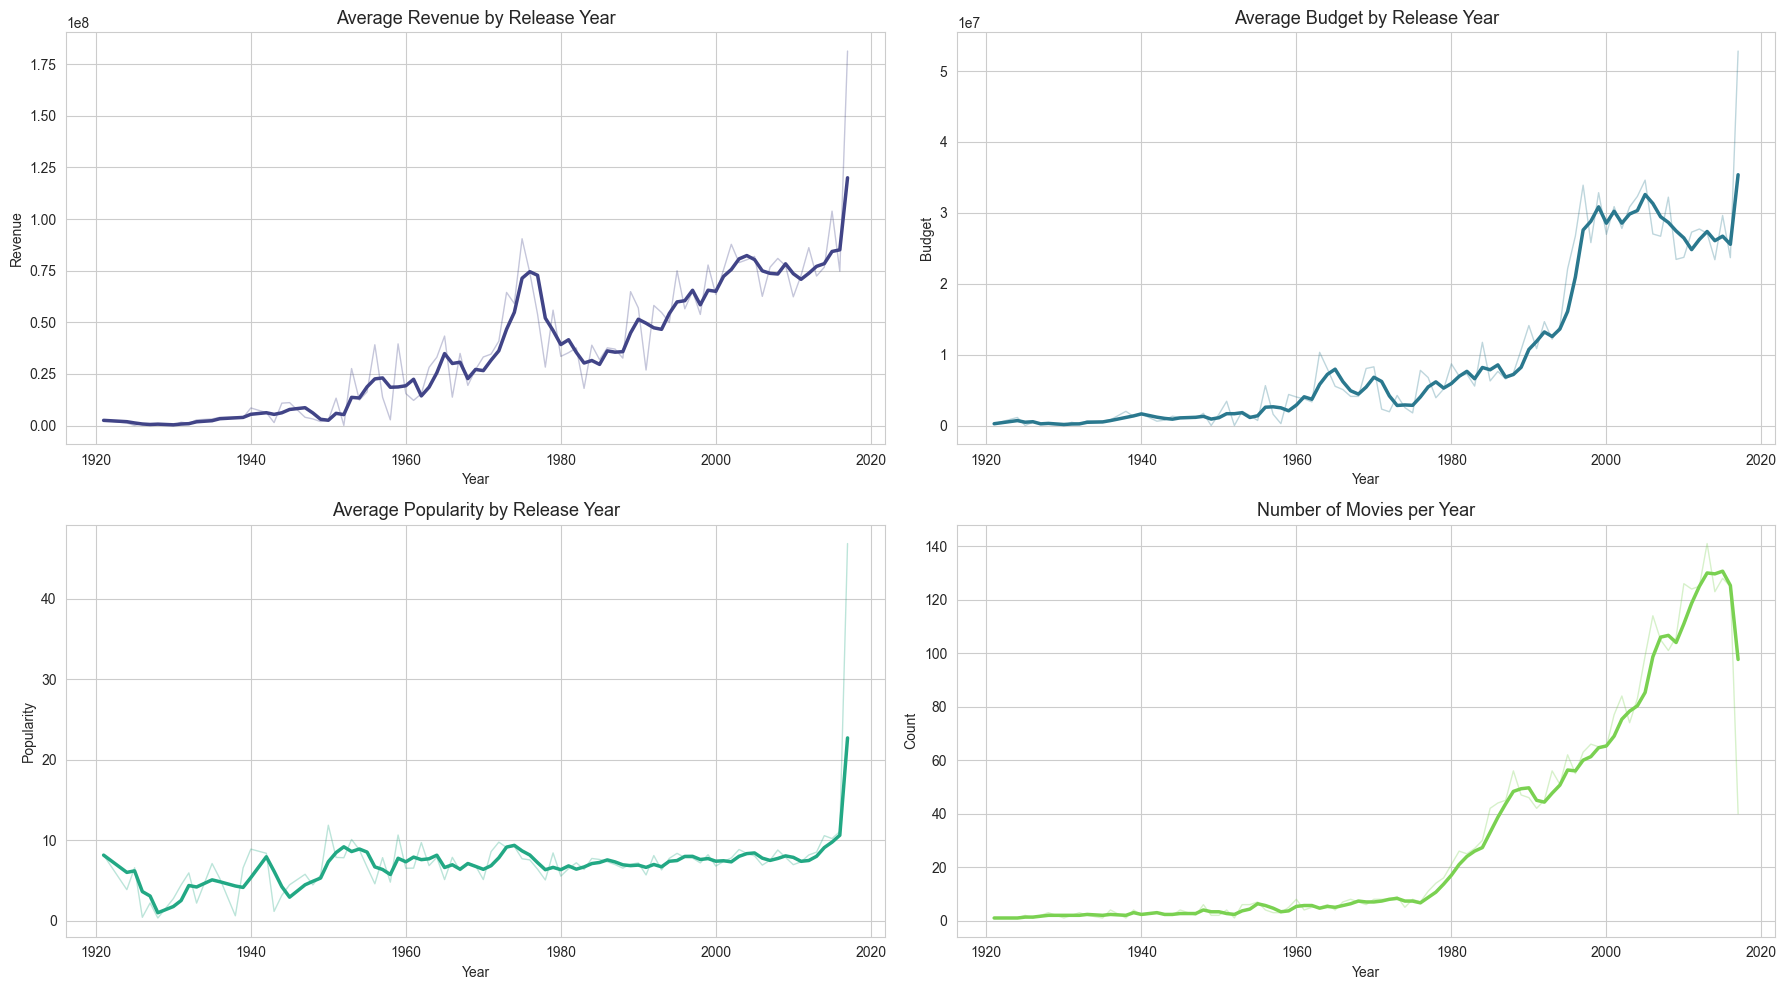

In [8]:
sns.set_style("whitegrid")
release_year = pd.to_datetime(train['release_date'], errors='coerce').dt.year
palette = sns.color_palette("viridis", 4)
release_year_plots = [
    {
        'data': train.groupby(release_year)['revenue'].mean().sort_index(),
        'color': palette[0],
        'title': 'Average Revenue by Release Year',
        'ylabel': 'Revenue'
    },
    {
        'data': train.groupby(release_year)['budget'].mean().sort_index(),
        'color': palette[1],
        'title': 'Average Budget by Release Year',
        'ylabel': 'Budget'
    },
    {
        'data': train.groupby(release_year)['popularity'].mean().sort_index(),
        'color': palette[2],
        'title': 'Average Popularity by Release Year',
        'ylabel': 'Popularity'
    },
    {
        'data': train.groupby(release_year).size().sort_index(),
        'color': palette[3],
        'title': 'Number of Movies per Year',
        'ylabel': 'Count'
    }
]

plt.figure(figsize=(18, 10))

for i, plot in enumerate(release_year_plots, 1):
    plt.subplot(2, 2, i)
    
    data = plot['data']
    smooth = data.rolling(window=3, min_periods=1).mean()
    
    sns.lineplot(x=data.index, y=data.values, color=plot['color'], alpha=0.3, linewidth=1)
    sns.lineplot(x=smooth.index, y=smooth.values, color=plot['color'], linewidth=2.5)
    
    plt.title(plot['title'], fontsize=13)
    plt.xlabel('Year')
    plt.ylabel(plot['ylabel'])

plt.tight_layout()
plt.show()

- **Revenue by Release Year**: Average revenue generally increases over time, with noticeable fluctuations and a sharp peak in the most recent years. This suggests that movies tend to generate higher revenues in more recent periods.
- **Budget by Release Year**: Movie budgets show a clear upward trend, especially from the 1990s onward, indicating that film production has become increasingly expensive over time.
- **Popularity by Release Year**: Popularity remains relatively stable for many decades but rises sharply in the most recent years, likely reflecting changes in how popularity is measured or the growing influence of digital platforms.
- **Movies Count per Release Year**: The number of movies released each year steadily increases, particularly after the 1980s, suggesting significant growth in film production over time.

### 2.3 Budget

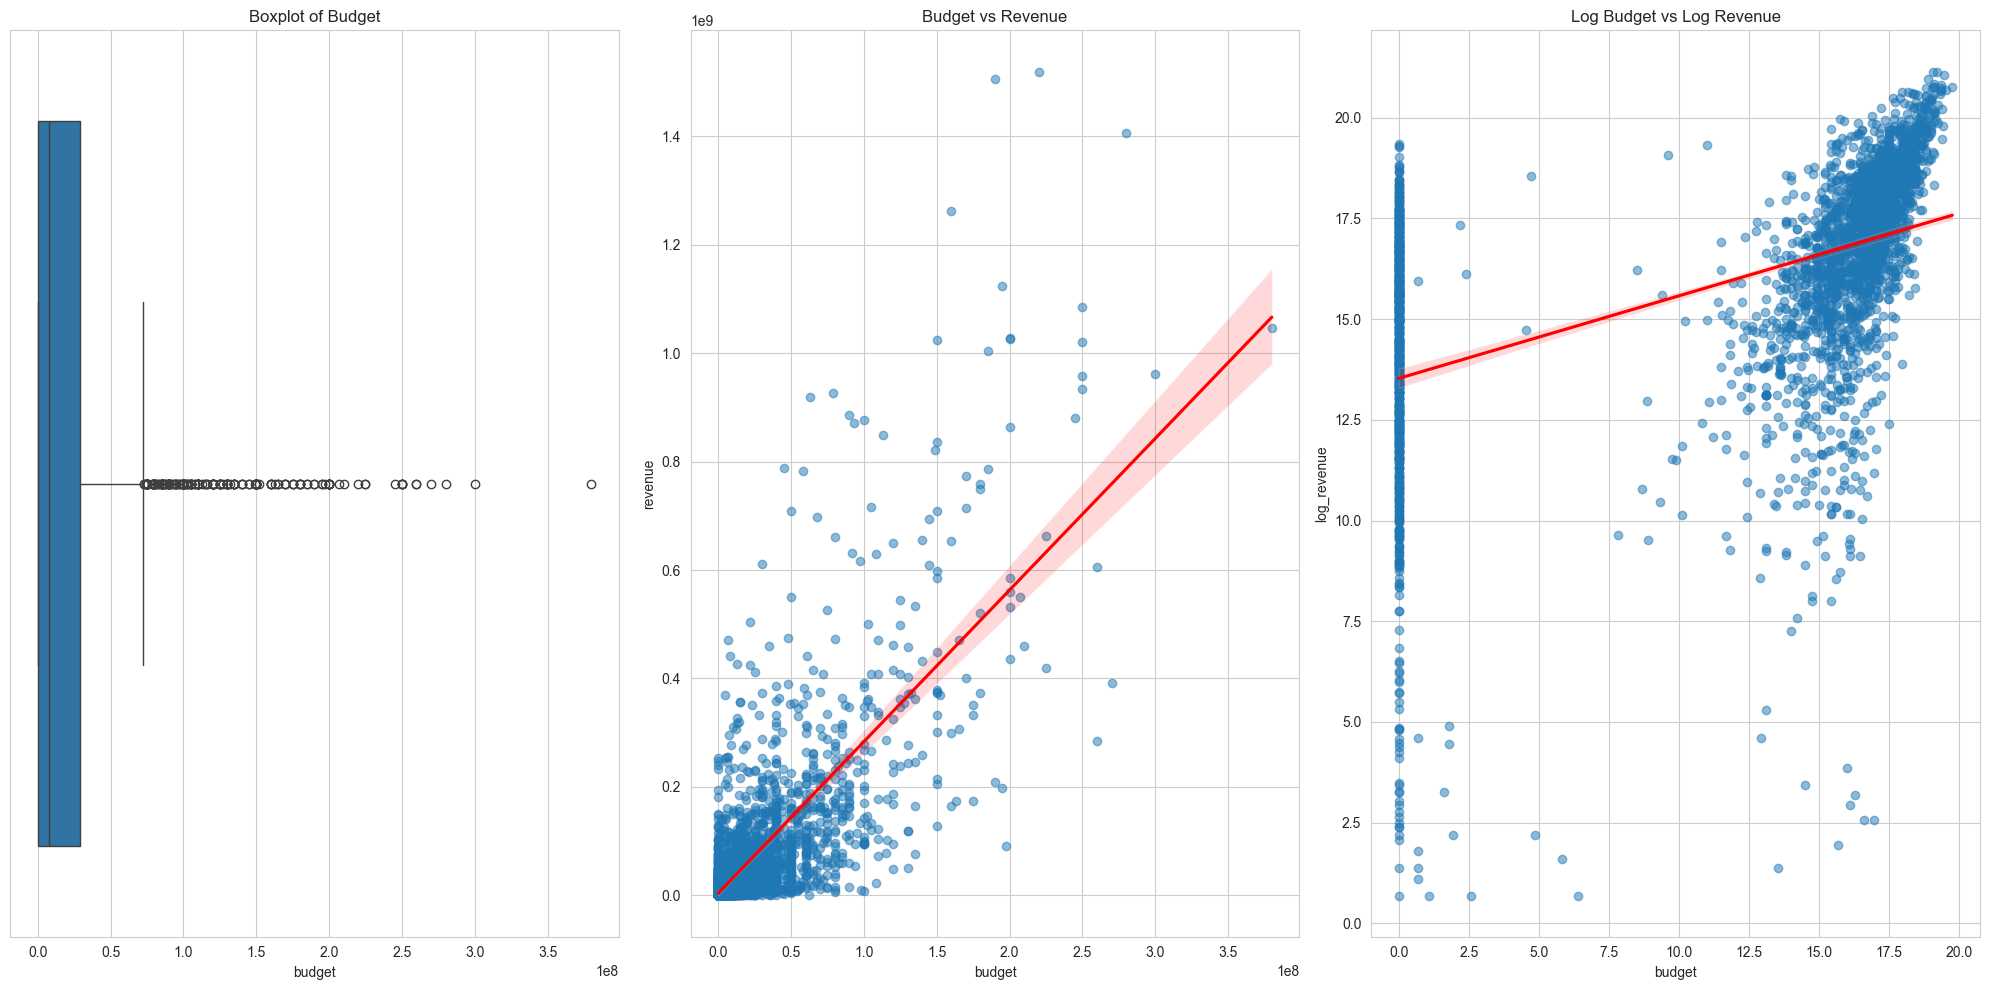

In [9]:
# Plots of the Budget distribution for train set
plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
sns.boxplot(x=train['budget'])
plt.title('Boxplot of Budget')
plt.subplot(1, 3, 2)
sns.regplot(x='budget', y='revenue', data=train, scatter_kws={'alpha':0.5}, line_kws={'color':'red'},)
plt.title('Budget vs Revenue')
plt.subplot(1, 3, 3)
sns.regplot(x=np.log1p(train['budget']), y=train['log_revenue'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Log Budget vs Log Revenue')
plt.tight_layout()
plt.show()

- **Boxplot of Budget**: The budget distribution is highly right-skewed, with most movies having relatively low budgets and several extreme outliers corresponding to very expensive productions.
- **Budget vs Revenue**: There is a positive relationship between budget and revenue: higher-budget movies tend to generate higher revenues, although the variance is large, indicating that high investment does not guarantee high revenue.
- **Log Budget vs Log Revenue**: After applying the logarithmic transformation, the relationship becomes more linear and clearer, suggesting that budget is a meaningful predictor of revenue and that the log transformation helps stabilize the variance.

### 2.3 Genres

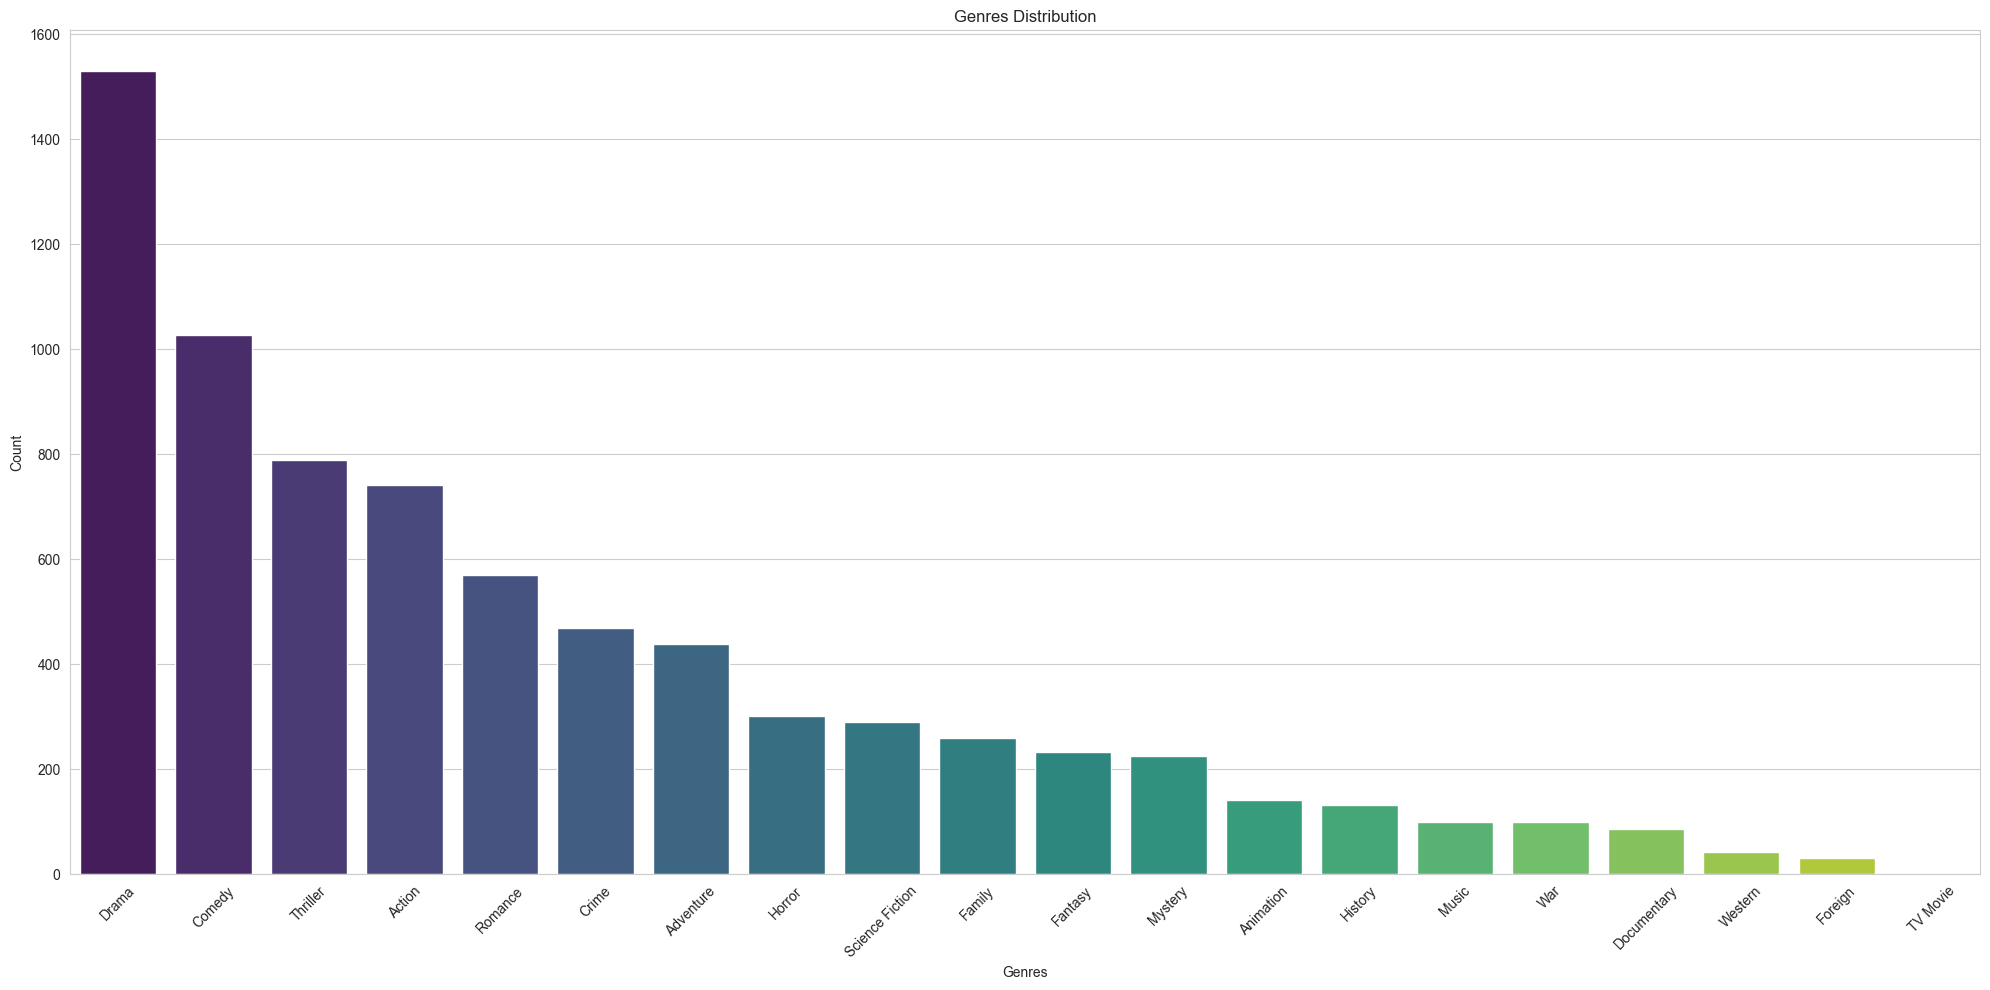

In [10]:
genres = train['genres'].explode().value_counts().reset_index()
# Plots of the Genres distribution for train set
plt.figure(figsize=(20, 10))
sns.barplot(x='genres', y='count', data=genres, palette='viridis', hue='genres', legend=False)
plt.title('Genres Distribution')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2.4 Homepage

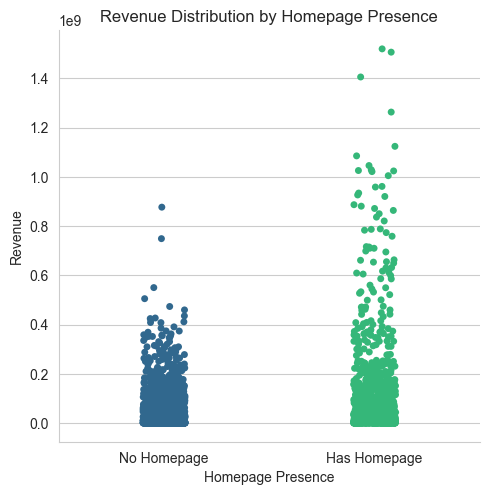

In [11]:
sns.catplot(
    x=train['homepage'].notna().astype(int), 
    y=train['revenue'],
    palette='viridis',
    hue=train['homepage'].notna().astype(int),
    legend=False
)
plt.title('Revenue Distribution by Homepage Presence')
plt.xticks([0, 1], ['No Homepage', 'Has Homepage'])
plt.xlabel('Homepage Presence')
plt.ylabel('Revenue')
plt.show()

The plot shows that movies with a homepage tend to generate higher revenues compared to those without one. Films without a homepage are mostly concentrated at lower revenue levels, while movies with a homepage exhibit a wider distribution and include many of the highest-grossing titles. This suggests that the presence of a homepage may be associated with larger productions or stronger marketing efforts.

### 2.5 Original Language

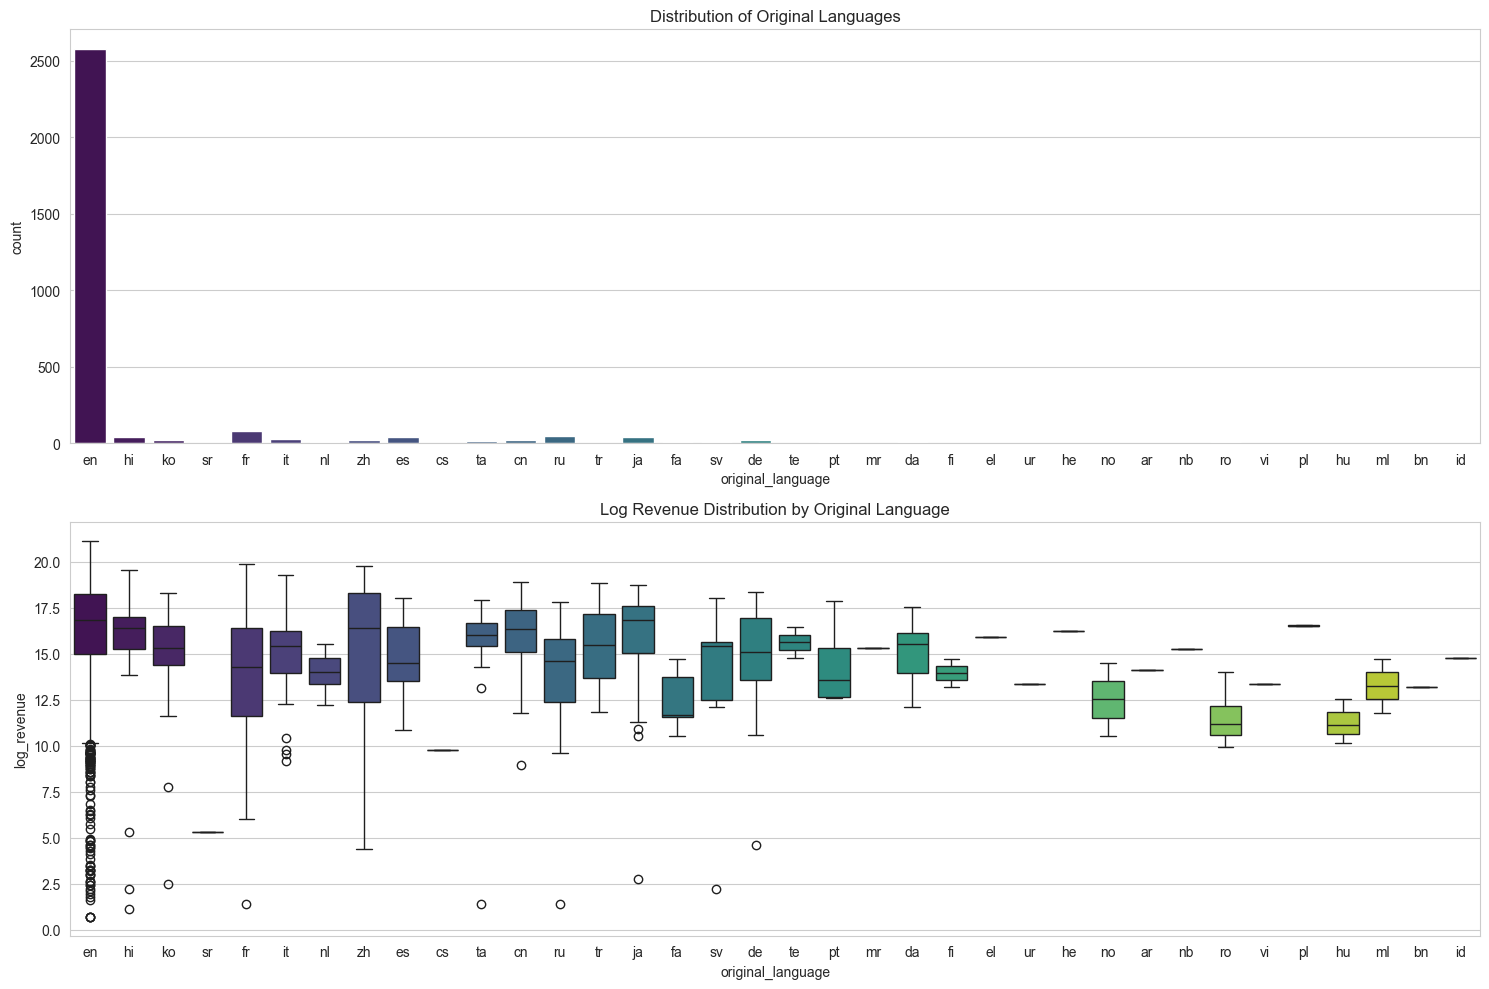

In [12]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.title("Distribution of Original Languages")
sns.countplot(x='original_language', data=train, palette='viridis', hue='original_language', legend=False)

plt.subplot(2, 1, 2)
plt.title("Log Revenue Distribution by Original Language")
sns.boxplot(x='original_language', y='log_revenue', data=train, palette='viridis', hue='original_language', legend=False)

plt.tight_layout()
plt.show()

The plot suggests that original language may affect the revenue, with english movies showing higher medians and much greater variability. Other languages generally exhibit lower and more concentrated revenue distributions, likely reflecting more localized markets.

### 2.6 Production Companies

Number of distinct production companies: 3695


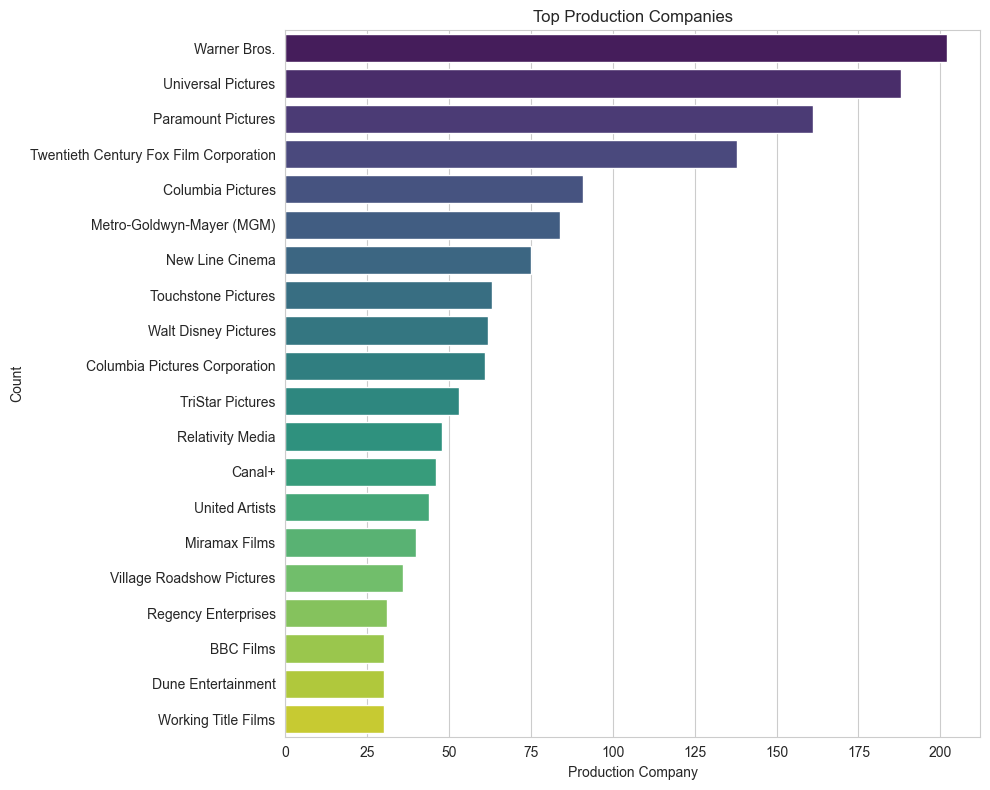

In [13]:
production_companies = train['production_companies'].explode().value_counts().reset_index()

print(f"Number of distinct production companies: {len(production_companies)}")
plt.figure(figsize = (10, 8))
sns.barplot(
    x='count',
    y='production_companies',
    data=production_companies.head(20),
    palette='viridis',
    hue='production_companies',
    legend=False
)
plt.title('Top Production Companies')
plt.xlabel('Production Company')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The distribution of production companies is highly skewed: a small number of major studios appear frequently, while most companies occur only a few times. This confirms that the feature has very high cardinality and suggests that retaining only the most frequent companies is a reasonable strategy to reduce sparsity and improve generalization.

### 2.7 Production Countries

Number of distinct production countries: 74


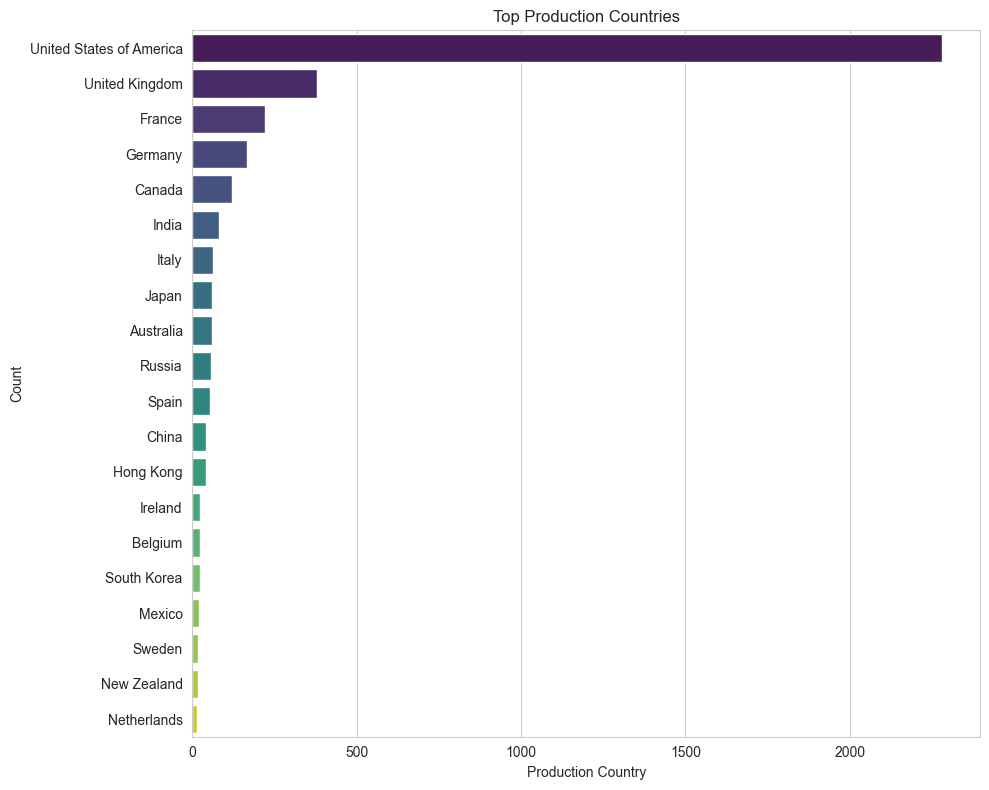

In [14]:
production_countries = train['production_countries'].explode().value_counts().reset_index()
print(f"Number of distinct production countries: {len(production_countries)}")

plt.figure(figsize = (10, 8))
sns.barplot(
    x='count',
    y='production_countries',
    data=production_countries.head(20),
    palette='viridis',
    hue='production_countries',
    legend=False
)
plt.title('Top Production Countries')
plt.xlabel('Production Country')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

As shown in the plot, the vast majority of films were produced in the United States, while many other production countries appear only once in the dataset. To mitigate overfitting and reduce sparsity, it is reasonable to retain only countries with a sufficient number of observations (e.g., more than 30 films)

### 2.8 Spoken Languages

Number of distinct spoken languages: 79


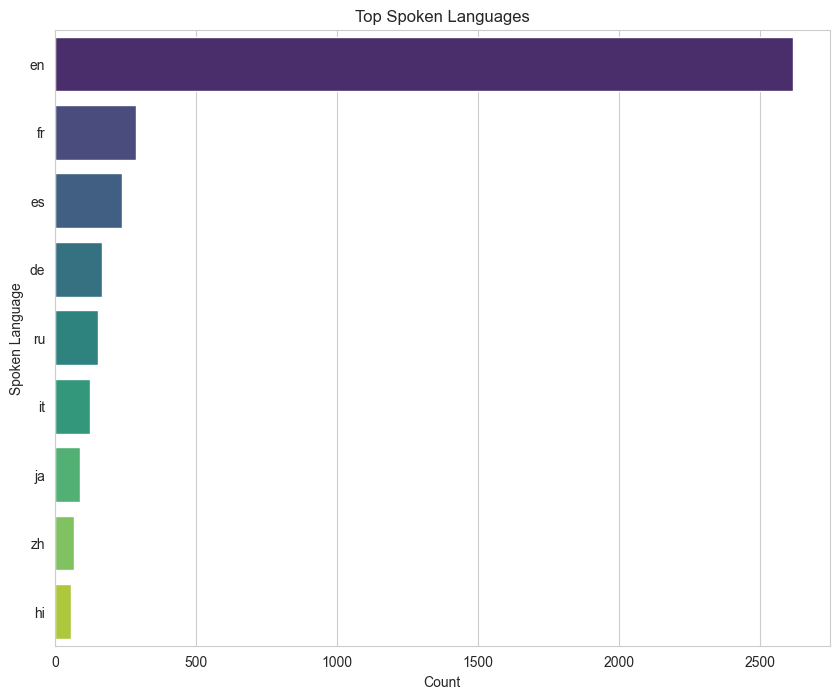

In [15]:
spoken_languages = train['spoken_languages'].explode().value_counts().reset_index()
top_spoken_languages = spoken_languages[spoken_languages['count'] > 50]

print(f"Number of distinct spoken languages: {len(spoken_languages)}")
plt.figure(figsize=(10, 8))
sns.barplot(x='count', y='spoken_languages', data=top_spoken_languages, palette=sns.color_palette('viridis', n_colors=len(top_spoken_languages)), hue='spoken_languages', dodge=False, legend=False)
plt.title('Top Spoken Languages')
plt.xlabel('Count')
plt.ylabel('Spoken Language')
plt.show()

The distribution of spoken languages is highly imbalanced, with English dominating the dataset by a large margin. Other languages such as French, Spanish, German, and Russian appear much less frequently, while languages like Italian, Japanese, Chinese, and Hindi have relatively few occurrences.

### 2.9 Tagline

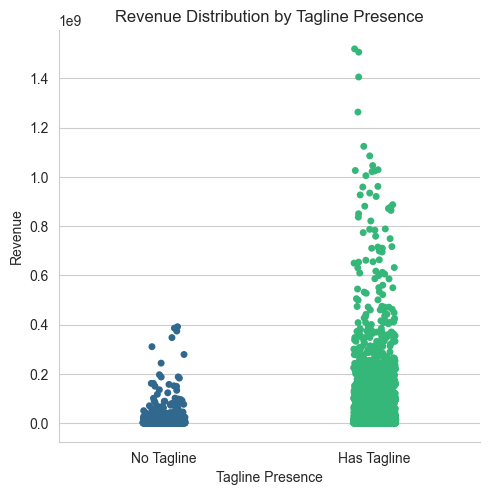

In [16]:
sns.catplot(
    x=train['tagline'].notna().astype(int), 
    y=train['revenue'],
    palette='viridis',
    hue=train['tagline'].notna().astype(int),
    legend=False
)
plt.title('Revenue Distribution by Tagline Presence')
plt.xticks([0, 1], ['No Tagline', 'Has Tagline'])
plt.xlabel('Tagline Presence')
plt.ylabel('Revenue')
plt.show()

The plot shows that movies with a tagline tend to achieve higher revenues compared to those without one. Films without a tagline are mostly concentrated at lower revenue values, while movies with a tagline display a wider spread and include many high-revenue outliers. This suggests that the presence of a tagline may be associated with stronger promotion or higher-budget productions.

### 2.10 Keywords

Number of distinct keywords: 7400


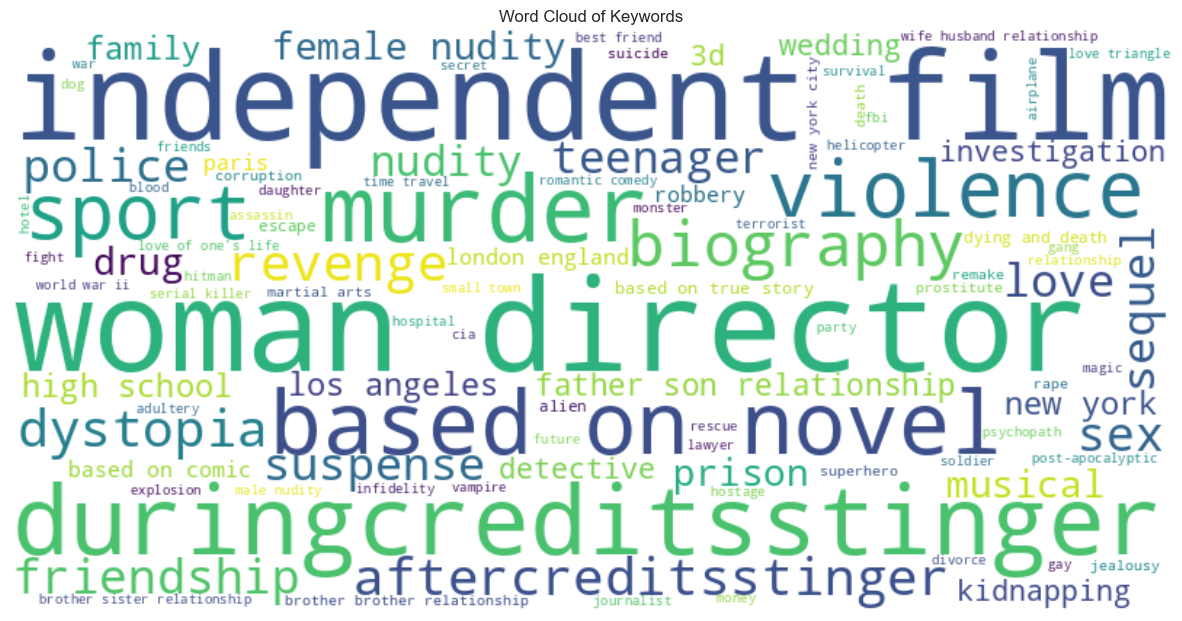

In [17]:
keywords = train['Keywords'].explode().value_counts().reset_index()

print(f"Number of distinct keywords: {len(keywords)}")

plt.figure(figsize=(15, 15))
plt.imshow(WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate_from_frequencies(
    dict(zip(keywords['Keywords'], keywords['count']))
), interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Keywords')
plt.show()

### 2.11 Cast

Number of distinct actors: 38588


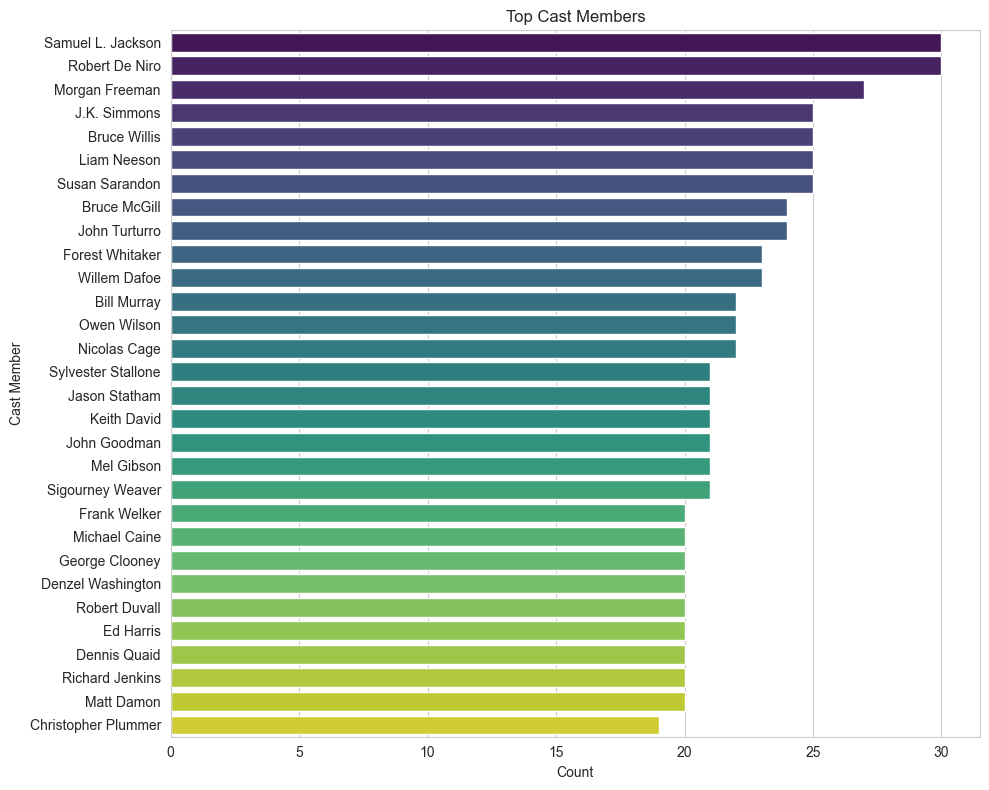

In [18]:
cast_count = train['cast'].explode().value_counts().reset_index()

print(f"Number of distinct actors: {len(cast_count)}")
plt.figure(figsize=(10, 8))
sns.barplot(x='count', y='cast', data=cast_count.head(30), palette='viridis', hue='cast', legend=False)
plt.title('Top Cast Members')
plt.xlabel('Count')
plt.ylabel('Cast Member')
plt.tight_layout()
plt.show()

### 2.12 Crew

Number of distinct directors: 1857


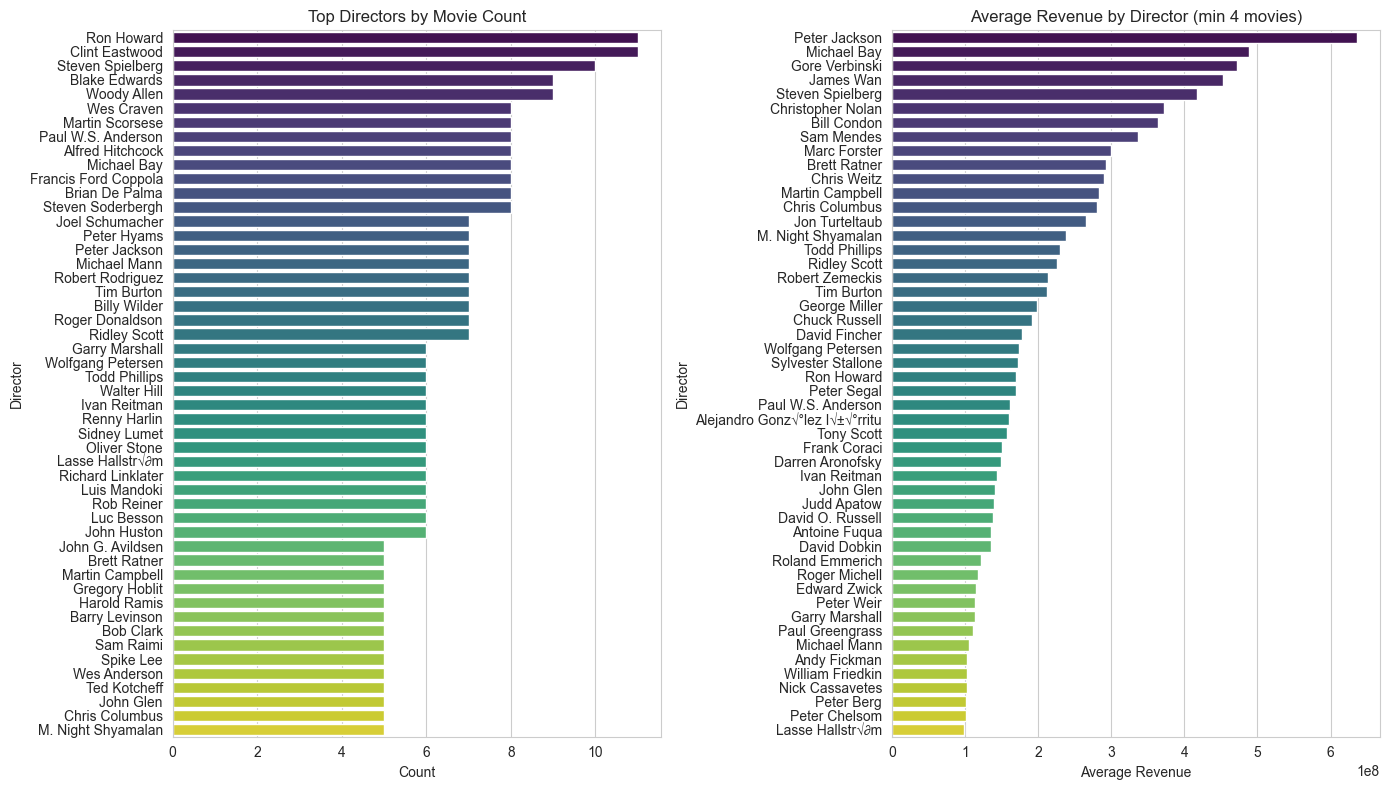

In [19]:
directors_count = train['director'].value_counts()
top_directors = directors_count[directors_count >= 4]

print(f"Number of distinct directors: {train['director'].nunique()}")

plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
sns.barplot(
    x=top_directors.head(50).values,
    y=top_directors.head(50).index,
    palette="viridis",
    hue=top_directors.head(50).index,
    legend=False
)

plt.title("Top Directors by Movie Count")
plt.xlabel("Count")
plt.ylabel("Director")

director_revenue = (
    train[train['director'].isin(top_directors.index)]
    .groupby('director')['revenue']
    .mean()
    .sort_values(ascending=False)
    .head(50)
)

plt.subplot(1,2,2)

sns.barplot(
    x=director_revenue.values,
    y=director_revenue.index,
    palette="viridis",
    hue=director_revenue.index,
    legend=False
)

plt.title("Average Revenue by Director (min 4 movies)")
plt.xlabel("Average Revenue")
plt.ylabel("Director")

plt.tight_layout()
plt.show()

### 2.13 Popularity

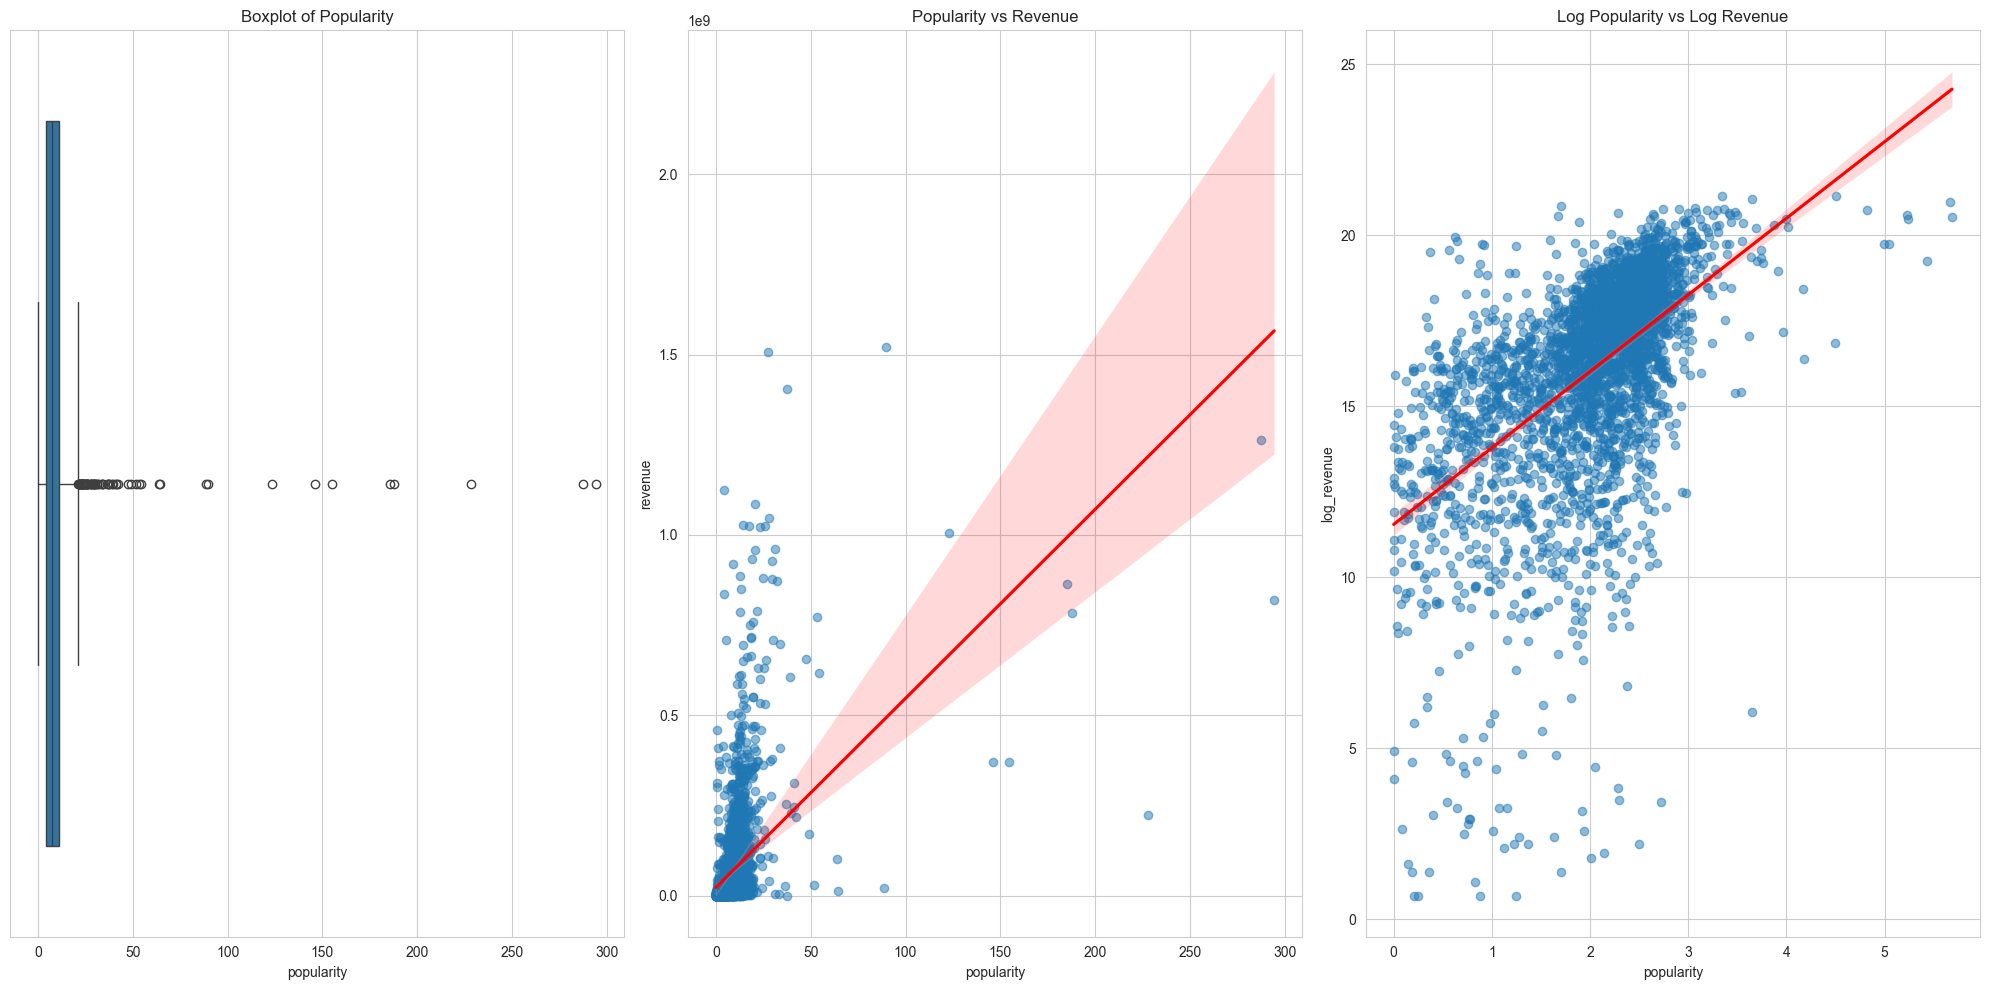

In [20]:
# Plots of the Popularity distribution for train set
plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
sns.boxplot(x=train['popularity'])
plt.title('Boxplot of Popularity')
plt.subplot(1, 3, 2)
sns.regplot(x='popularity', y='revenue', data=train, scatter_kws={'alpha':0.5}, line_kws={'color':'red'},)
plt.title('Popularity vs Revenue')
plt.subplot(1, 3, 3)
sns.regplot(x=np.log1p(train['popularity']), y=train['log_revenue'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Log Popularity vs Log Revenue')
plt.tight_layout()
plt.show()


- **Boxplot of Popularity**: The popularity distribution is strongly right-skewed, with most movies having relatively low popularity and several extreme outliers with very high values.
- **Popularity vs Revenue**: There is a positive relationship between popularity and revenue, although the dispersion is large, indicating that highly popular movies tend to earn more but with considerable variability.
- **Log Popularity vs Log Revenue**: After applying the logarithmic transformation, the relationship becomes more linear and clearer, suggesting that popularity is a useful predictor of revenue and that the log transformation helps stabilize the variance.

### 2.14 Belongs To Collection

Number of distinct collections: 422


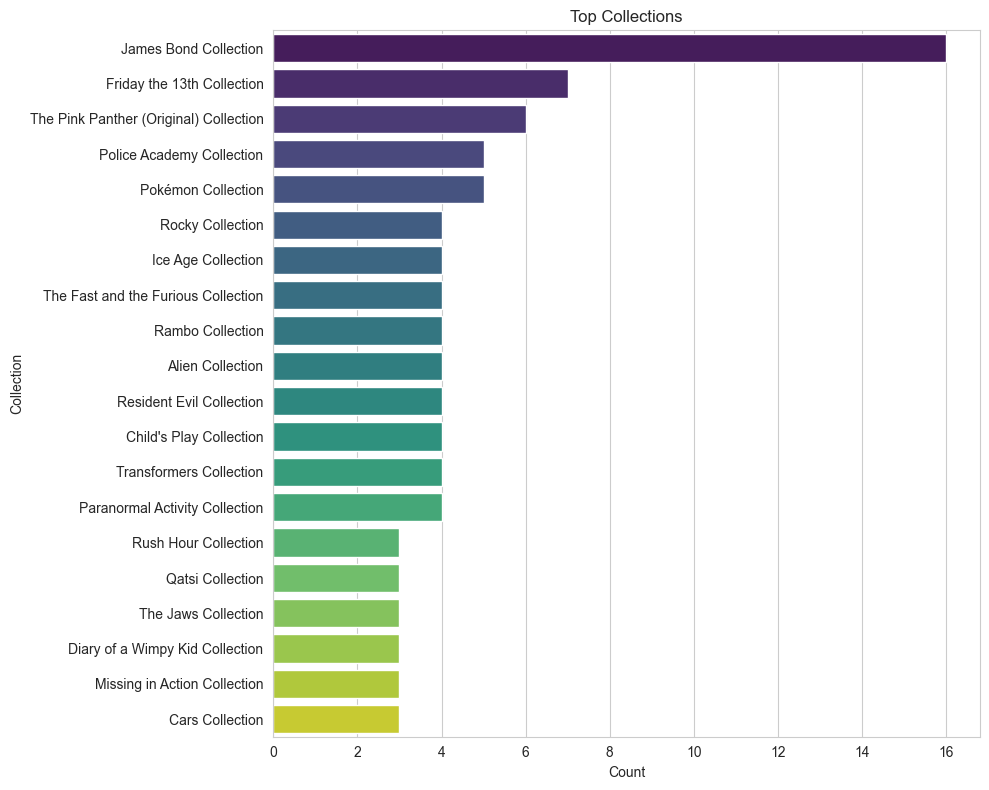

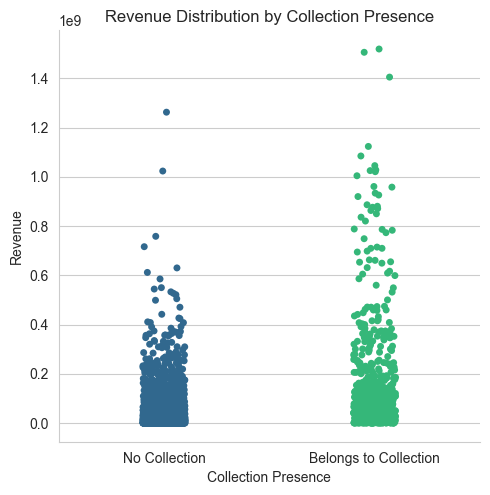

In [21]:
collections = train['belongs_to_collection'].explode().value_counts().reset_index()

print(f"Number of distinct collections: {len(collections)}")
plt.figure(figsize=(10, 8))
sns.barplot(x='count', y='belongs_to_collection', data=collections.head(20), palette=sns.color_palette('viridis', n_colors=20), hue='belongs_to_collection', dodge=False, legend=False)
plt.title('Top Collections')
plt.xlabel('Count')
plt.ylabel('Collection')
plt.tight_layout()
plt.show()

collections_analysis = train.copy()
collections_analysis['belongs_to_collection'] = collections_analysis['belongs_to_collection'].apply(lambda x: 1 if len(x) > 0 else 0)

sns.catplot(
    x=collections_analysis['belongs_to_collection'], 
    y=collections_analysis['revenue'],
    palette='viridis',
    hue=collections_analysis['belongs_to_collection'],
    legend=False
)
plt.title('Revenue Distribution by Collection Presence')
plt.xticks([0, 1], ['No Collection', 'Belongs to Collection'])
plt.xlabel('Collection Presence')
plt.ylabel('Revenue')
plt.show()

The plot shows that movies belonging to a collection tend to generate higher revenues compared to standalone films. While movies without a collection are mostly concentrated at lower revenue levels, films that are part of a collection exhibit a wider distribution and include many of the highest-grossing titles. This suggests that franchises or sequels are often associated with greater commercial success.

## 3. Feature Engineering

In [22]:
X = train.drop(columns=['revenue', 'log_revenue'])
y = train['log_revenue']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=random_state)
print(f"Size of the training set: {X_train.shape[0]} samples")
print(f"Size of the validation set: {X_val.shape[0]} samples")

Size of the training set: 2400 samples
Size of the validation set: 600 samples


### 3.1 Release Date

The revenue of a movie may be influenced by its release date, particularly when it is released during specific periods of the year associated with higher audience demand. For this reason, we extract a set of informative temporal features from the release date to capture potential seasonal effects and release timing patterns.

In [23]:
def process_release_date(df):
    df = df.copy()

    df['release_year'] = df['release_date'].dt.year
    df['release_month'] = df['release_date'].dt.month
    df['release_day'] = df['release_date'].dt.day
    df['release_weekday'] = df['release_date'].dt.weekday

    month = df['release_month']
    df['is_summer_release'] = month.isin([5, 6, 7, 8]).astype(int)
    df['is_holiday_release'] = month.isin([11, 12]).astype(int)
    df['is_awards_season_release'] = month.isin([10, 11, 12]).astype(int)
    df['is_dump_month_release'] = month.isin([1, 2, 9]).astype(int)

    df['release_quarter'] = ((month - 1) // 3 + 1).astype(int)

    df = df.drop(columns=['release_date'])

    return df

X_train = process_release_date(X_train)
X_val = process_release_date(X_val)
test = process_release_date(test)

### 3.2 Belongs To Collection

In [24]:
def process_belongs_to_collection(df):
    df['belongs_to_collection'] = df['belongs_to_collection'].apply(lambda x: 1 if len(x) > 0 else 0)
    return df

### 3.3 Budget

Since a large number of movies in the dataset have a budget equal to zero, which is unrealistic for actual film productions, these values are likely placeholders for missing data rather than true budgets. To address this issue, we replace zero budgets with the **median budget of movies released in the same year**.

Using the median instead of the mean makes the imputation more robust to extreme values, since movie budgets are highly skewed: a small number of blockbuster films can have budgets that are orders of magnitude larger than typical productions. Additionally, imputing the budget based on the **release year** accounts for changes in production costs over time (e.g., inflation and industry growth), ensuring that the imputed value is consistent with the economic context of that period.

In [25]:
median_budget_per_year = X_train.loc[X_train['budget'] > 0].groupby('release_year')['budget'].median()
global_budget_median = X_train.loc[X_train['budget'] > 0, 'budget'].median()

def budget_preprocessing(df):
    df['budget'] = df['budget'].astype(float)
    df['budget_is_zero'] = (df['budget'] == 0).astype(int)

    year_median = df['release_year'].map(median_budget_per_year)
    year_median = year_median.fillna(global_budget_median)

    df.loc[df['budget'] == 0, 'budget'] = year_median[df['budget'] == 0]
    df['log_budget'] = np.log1p(df['budget'])

    return df

### 3.4 Genres

Genres are naturally a multi-label categorical feature, since a movie may belong to more than one genre at the same time. Therefore, a standard one-hot encoding would not be appropriate in its usual single-category form.

To represent this information, we use a multi-hot encoding through `MultiLabelBinarizer`, creating one binary feature for each genre. This preserves the full genre composition of each movie and allows the models to learn which genres, or combinations of genres, are associated with higher or lower revenues.

In [26]:
def process_genres(df, mlb):
    genre_encoded = mlb.transform(df['genres'])
    genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_, index=df.index).add_prefix('genre_')
    df = pd.concat([df.drop(columns=['genres']), genre_df], axis=1)
    return df

genres_mlb = MultiLabelBinarizer()
genres_mlb.fit(X_train['genres'])

,"classes classes: array-like of shape (n_classes,), default=NoneIndicates an ordering for the class labels.All entries should be unique (cannot contain duplicate classes).",None
,"sparse_output sparse_output: bool, default=FalseSet to True if output binary array is desired in CSR sparse format.",False


### 3.5 Homepage

In [27]:
def process_homepage(df):
    df['has_homepage'] = df['homepage'].notna().astype(int)
    df = df.drop(columns=['homepage'])
    return df

### 3.6 Original Language

In [28]:
def map_original_languages(df, top_original_languages):
    df['original_language'] = df['original_language'].where(
        df['original_language'].isin(top_original_languages),
        'other'
    )
    return df

def encode_original_languages(df, encoder):
    encoded_cols = encoder.get_feature_names_out(['original_language'])
    encoded_df = pd.DataFrame(encoder.transform(df[['original_language']]), columns=encoded_cols, index=df.index)
    df = pd.concat([df.drop(columns=['original_language']), encoded_df], axis=1)
    return df

top_original_languages = X_train['original_language'].value_counts().head(10).index.to_list()
print(f"Top 10 Original Languages:\n{top_original_languages}")

X_train = map_original_languages(X_train, top_original_languages)
original_language_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
original_language_ohe.fit(X_train[['original_language']])

Top 10 Original Languages:
['en', 'fr', 'ru', 'hi', 'es', 'ja', 'it', 'ko', 'de', 'cn']


,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

### 3.7 Production Companies

The `production_companies` field contains a large number of distinct labels, making it a high-cardinality multi-label feature. Encoding every company would lead to an excessively sparse design matrix and would likely introduce noise from very infrequent categories.

To address this issue, we keep only the top 20 most frequent production companies in the training set and encode them using `MultiLabelBinarizer`. This preserves the information associated with the most relevant studios while limiting dimensionality. We also create an additional feature representing the total number of production companies involved in each film.

In [29]:
def transform_production_companies(df, mlb):
    df['num_production_companies'] = df['production_companies'].apply(len)

    filtered_companies = df['production_companies'].apply(
        lambda x: [k for k in x if k in mlb.classes_] if isinstance(x, list) else []
    )
    
    encoded = mlb.transform(filtered_companies)
    
    production_companies_df = pd.DataFrame(
        encoded, 
        columns=mlb.classes_, 
        index=df.index
    ).add_prefix('production_company_')

    return pd.concat([df.drop(columns=['production_companies']), production_companies_df], axis=1)

production_companies = X_train['production_companies'].explode().value_counts()
top_companies = production_companies.head(20).index.tolist()

production_companies_mlb = MultiLabelBinarizer(classes=top_companies)
production_companies_mlb.fit(X_train['production_companies'])

print(f"The top {len(top_companies)} production companies are {top_companies}")

The top 20 production companies are ['Warner Bros.', 'Universal Pictures', 'Paramount Pictures', 'Twentieth Century Fox Film Corporation', 'Columbia Pictures', 'Metro-Goldwyn-Mayer (MGM)', 'New Line Cinema', 'Touchstone Pictures', 'Columbia Pictures Corporation', 'Walt Disney Pictures', 'TriStar Pictures', 'Canal+', 'Relativity Media', 'United Artists', 'Village Roadshow Pictures', 'Miramax Films', 'Regency Enterprises', 'Dune Entertainment', 'Fox Searchlight Pictures', 'Lionsgate']


### 3.8 Production Countries
Production countries are encoded as a multi-label categorical feature because a movie can be associated with more than one country. As with production companies, the distribution is highly imbalanced, with a small number of countries accounting for most observations.

To reduce sparsity and avoid overfitting, we retain only countries appearing more than 30 times in the training set. The selected countries are then encoded with `MultiLabelBinarizer`. In addition, we compute the number of production countries for each movie as a separate numerical feature.

In [30]:
def transform_production_countries(df, mlb):
    df['num_production_countries'] = df['production_countries'].apply(len)

    filtered_countries = df['production_countries'].apply(
        lambda x: [k for k in x if k in mlb.classes_] if isinstance(x, list) else []
    )

    encoded = mlb.transform(filtered_countries)
    production_countries_df = pd.DataFrame(
        encoded, 
        columns=mlb.classes_, 
        index=df.index
    ).add_prefix('production_country_')

    return pd.concat([df.drop(columns=['production_countries']), production_countries_df], axis=1)

production_countries = X_train['production_countries'].explode().value_counts()
top_countries = production_countries[production_countries > 30].index.tolist()

production_countries_mlb = MultiLabelBinarizer(classes=top_countries)
production_countries_mlb.fit(X_train['production_countries'])

print(f"The top {len(top_countries)} production countries are {top_countries}")

The top 13 production countries are ['United States of America', 'United Kingdom', 'France', 'Germany', 'Canada', 'India', 'Australia', 'Italy', 'Russia', 'Japan', 'Spain', 'China', 'Hong Kong']


### 3.9 Spoken Languages

In [31]:
def transform_spoken_languages(df, mlb):    
    df['num_spoken_languages'] = df['spoken_languages'].apply(len)

    filtered_spoken_languages = df['spoken_languages'].apply(
        lambda x: [k for k in x if k in mlb.classes_] if isinstance(x, list) else []
    )

    encoded = mlb.transform(filtered_spoken_languages)
    spoken_languages_df = pd.DataFrame(
        encoded, 
        columns=mlb.classes_, 
        index=df.index
    ).add_prefix('spoken_language_')

    return pd.concat([df.drop(columns=['spoken_languages']), spoken_languages_df], axis=1)

spoken_languages = X_train['spoken_languages'].explode().value_counts()
top_spoken_languages = spoken_languages[spoken_languages > 30].index.to_list()

spoken_languages_mlb = MultiLabelBinarizer(classes=top_spoken_languages)
spoken_languages_mlb.fit(X_train['spoken_languages'])

print(f"The top {len(top_spoken_languages)} spoken languages are {top_spoken_languages}")

The top 12 spoken languages are ['en', 'fr', 'es', 'de', 'ru', 'it', 'ja', 'zh', 'hi', 'ar', 'pt', 'ko']


### 3.10 Tagline

In [32]:
def process_tagline(df):
    df['has_tagline'] = df['tagline'].apply(lambda x: 0 if pd.isna(x) else 1)
    return df.drop(columns=['tagline'])

### 3.11 Keywords

Keywords summarize themes, topics, and semantic elements of a movie, and may therefore provide valuable predictive information about box office performance. However, this field has extremely high cardinality, with thousands of distinct keywords in the dataset.

To prevent the feature space from becoming excessively sparse, we retain only the most frequent keywords and encode them with `MultiLabelBinarizer`. We also compute the total number of keywords assigned to each movie, which may reflect the richness or specificity of its metadata representation.

In [33]:
def process_keywords(df, mlb):
    df['num_keywords'] = df['Keywords'].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )

    filtered_keywords = df['Keywords'].apply(
        lambda x: [k for k in x if k in mlb.classes_] if isinstance(x, list) else []
    )

    encoded = mlb.transform(filtered_keywords)

    keywords_df = (
        pd.DataFrame(encoded, columns=mlb.classes_, index=df.index)
        .add_prefix("keyword_")
    )

    df = pd.concat([df, keywords_df], axis=1)

    return df.drop(columns=['Keywords'])

keywords_counts = X_train['Keywords'].explode().value_counts()
top_keywords = keywords_counts[keywords_counts > 50].index.tolist()

keywords_mlb = MultiLabelBinarizer(classes=top_keywords)
keywords_mlb.fit(X_train['Keywords'])

print(f"The top {len(top_keywords)} keywords are:\n{top_keywords}")

The top 15 keywords are:
['woman director', 'independent film', 'duringcreditsstinger', 'murder', 'based on novel', 'sport', 'violence', 'revenge', 'dystopia', 'friendship', 'aftercreditsstinger', 'sex', 'biography', 'love', 'suspense']


### 3.12 Cast

The cast information may capture the presence of well-known actors, which can influence audience interest and commercial performance. At the same time, the number of distinct cast members is extremely large, making a full encoding infeasible.

For this reason, we retain only the most frequent cast members in the training set and encode them as binary indicators using `MultiLabelBinarizer`. We additionally compute the number of cast members listed for each movie, since ensemble size may also contain useful information.

In [34]:
cast_count = X_train['cast'].explode().value_counts()
top_cast = cast_count[cast_count > 15].index.tolist()

def process_cast(df, mlb):
    filtered_cast = df['cast'].apply(
        lambda x: [k for k in x if k in mlb.classes_] if isinstance(x, list) else []
    )

    encoded = mlb.transform(filtered_cast)

    cast_df = pd.DataFrame(
        encoded, 
        columns=mlb.classes_, 
        index=df.index
    ).add_prefix('cast_')
    
    df = pd.concat([df.drop(columns=['cast']), cast_df], axis=1)
    return df

cast_mlb = MultiLabelBinarizer(classes=top_cast)
cast_mlb.fit(X_train['cast'])

print(f"The top {len(top_cast)} cast members are:\n{top_cast}")

The top 29 cast members are:
['Samuel L. Jackson', 'Morgan Freeman', 'Liam Neeson', 'J.K. Simmons', 'Robert De Niro', 'Bruce Willis', 'Bill Murray', 'Forest Whitaker', 'Willem Dafoe', 'Jason Statham', 'John Turturro', 'Bruce McGill', 'Susan Sarandon', 'Ed Harris', 'Robert Duvall', 'Sylvester Stallone', 'Denzel Washington', 'Philip Seymour Hoffman', 'Kevin Bacon', 'Steve Buscemi', 'Christopher Plummer', 'Nicolas Cage', 'Allison Janney', 'Michael Caine', 'Richard Jenkins', 'John Goodman', 'George Clooney', 'Christopher Walken', 'Dennis Quaid']


### 3.13 Crew

The `crew` field contains many different professional roles, but not all of them are equally informative for revenue prediction. Among them, the director is one of the most interpretable and potentially relevant signals, as directors may capture style, reputation, and production quality.

We therefore extract the director from the crew list and encode only the most frequent directors, grouping the remaining ones into an `other` category. This reduces the cardinality of the feature while preserving the information associated with directors who appear sufficiently often in the training set.

In [35]:
def map_director(df, top_directors):
    df = df.copy()
    df['director'] = df['director'].apply(lambda x: x if x in top_directors else 'other')
    return df

def process_crew(df, one_hot_encoder):
    df = df.copy()
    # crew size feature
    df['num_crew'] = df['crew'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    # encode director
    director_encoded = one_hot_encoder.transform(df[['director']])
    director_df = pd.DataFrame(
        director_encoded,
        columns=one_hot_encoder.get_feature_names_out(['director']),
        index=df.index
    ).astype(int)

    df = pd.concat([df.drop(columns=['director', 'crew']), director_df], axis=1)

    return df

# Top Directors
directors_count = X_train['director'].value_counts()
top_directors = directors_count[directors_count > 5].index.tolist()

X_train = map_director(X_train, top_directors)

director_ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)
director_ohe.fit(X_train[['director']])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

### 3.14 Popularity

In [36]:
def process_popularity(df):
    df['log_popularity'] = np.log1p(df['popularity'])
    return df

### 3.15 Runtime

In [37]:
median_runtime_per_year = X_train.loc[X_train['runtime'].notna() & (X_train['runtime'] > 0)].groupby('release_year')['runtime'].median()
global_runtime_median = X_train.loc[X_train['runtime'].notna() & (X_train['runtime'] > 0), 'runtime'].median()

def process_runtime(df):
    df = df.copy()
    df['runtime'] = df['runtime'].astype(float)

    missing_or_zero = df['runtime'].isna() | (df['runtime'] == 0)
    df['runtime_is_missing_or_zero'] = missing_or_zero.astype(int)

    year_median = df['release_year'].map(median_runtime_per_year).fillna(global_runtime_median)
    df.loc[missing_or_zero, 'runtime'] = year_median[missing_or_zero]

    df['log_runtime'] = np.log1p(df['runtime'])
    return df

### 3.16 Cross Features

In addition to the original predictors, we construct several interaction and ratio-based features in order to capture non-linear relationships between budget, popularity, and runtime. These variables aim to provide the models with more expressive information than the raw features alone.

In [38]:
def cross_features(df):
    df['log_budget_x_log_popularity'] = df['log_budget'] * df['log_popularity']
    df['budget_per_runtime'] = df['budget'] / df['runtime']
    df['popularity_per_runtime'] = df['popularity'] / df['runtime']
    df['popularity_to_budget'] = df['popularity'] / (df['budget'] + 1)
    df['log_budget_per_runtime'] = df['log_budget'] / np.log1p(df['runtime'])

    return df

### 3.17 Other Features

In [39]:
def process_other_features(df):
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
    return df.drop(columns=['imdb_id', 'title', 'original_title', 'overview', 'poster_path', 'status'])


### 3.18 Preprocessing Pipeline

In [40]:
def preprocessing_pipeline(df):
    df = df.copy()
    # Belongs to collection
    df = process_belongs_to_collection(df)
    # Budget
    df = budget_preprocessing(df)
    # Genres
    df = process_genres(df, genres_mlb)
    # Homepage
    df = process_homepage(df)
    # Original Language
    df['original_language'] = df['original_language'].where(df['original_language'].isin(top_original_languages), 'other')
    df = encode_original_languages(df, original_language_ohe)
    # Production Companies
    df = transform_production_companies(df, production_companies_mlb)
    # Production Countries
    df = transform_production_countries(df, production_countries_mlb)
    # Spoken Languages
    df = transform_spoken_languages(df, spoken_languages_mlb)
    # Tagline
    df = process_tagline(df)
    # Keywords
    df = process_keywords(df, keywords_mlb)
    # Cast
    df = process_cast(df, cast_mlb)
    # Crew
    df = map_director(df, top_directors)
    df = process_crew(df, director_ohe)
    # Popularity
    df = process_popularity(df)
    # Runtime
    df = process_runtime(df)
    # Cross features
    df = cross_features(df)
    # Other features
    df = process_other_features(df)

    return df

X_train = preprocessing_pipeline(X_train)
X_val = preprocessing_pipeline(X_val)
X_test = preprocessing_pipeline(test)

## 4. Model Tuning

In this section, we compare two tree-based regression models: Random Forest and XGBoost. These algorithms are well suited to tabular data and can naturally model non-linear relationships and complex feature interactions.

Hyperparameter tuning is performed using `RandomizedSearchCV` with 5-fold cross-validation. This approach allows us to explore a broad hyperparameter space while keeping the computational cost manageable.

In [41]:
results = []
y_val_real = np.expm1(y_val)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

### 4.1 Random Forest Regressor

In [42]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_dist_rf = {
    'n_estimators': [300, 500, 800],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.6, 0.8],
    'max_samples': [0.7, 0.8, 0.9]
}

search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search_rf.fit(X_train, y_train)

rf_best = search_rf.best_estimator_
y_pred_rf = rf_best.predict(X_val)
y_pred_rf_real = np.expm1(y_pred_rf)
rf_rmsle = root_mean_squared_log_error(y_val_real, y_pred_rf_real)

results.append({
    'model': 'Random Forest Regressor',
    'rmsle': rf_rmsle,
    'r2_score': r2_score(y_val, y_pred_rf),
})

print("Best hyperparameters for Random Forest:")
print(search_rf.best_params_)

Best hyperparameters for Random Forest:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_samples': 0.9, 'max_features': 0.6, 'max_depth': None}


### 4.2 XGBoost Regressor

In [43]:
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist_xgb = {
    "n_estimators": [1500, 2000],
    "learning_rate": [0.01, 0.02, 0.03],
    "max_depth": [4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.6, 0.7, 0.8],
    "colsample_bytree": [0.6, 0.7, 0.8],
    "gamma": [0, 0.1, 0.3],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 2, 3]
}

search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search_xgb.fit(X_train, y_train)

xgb_best = XGBRegressor(
    **search_xgb.best_params_,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100
)

xgb_best.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_pred_xgb = xgb_best.predict(X_val)
y_pred_xgb_real = np.expm1(y_pred_xgb)
xgb_rmsle = root_mean_squared_log_error(y_val_real, y_pred_xgb_real)

results.append({
    'model': 'XGBoost Regressor',
    'rmsle': xgb_rmsle,
    'r2_score': r2_score(y_val, y_pred_xgb),
})

### 4.5 Results

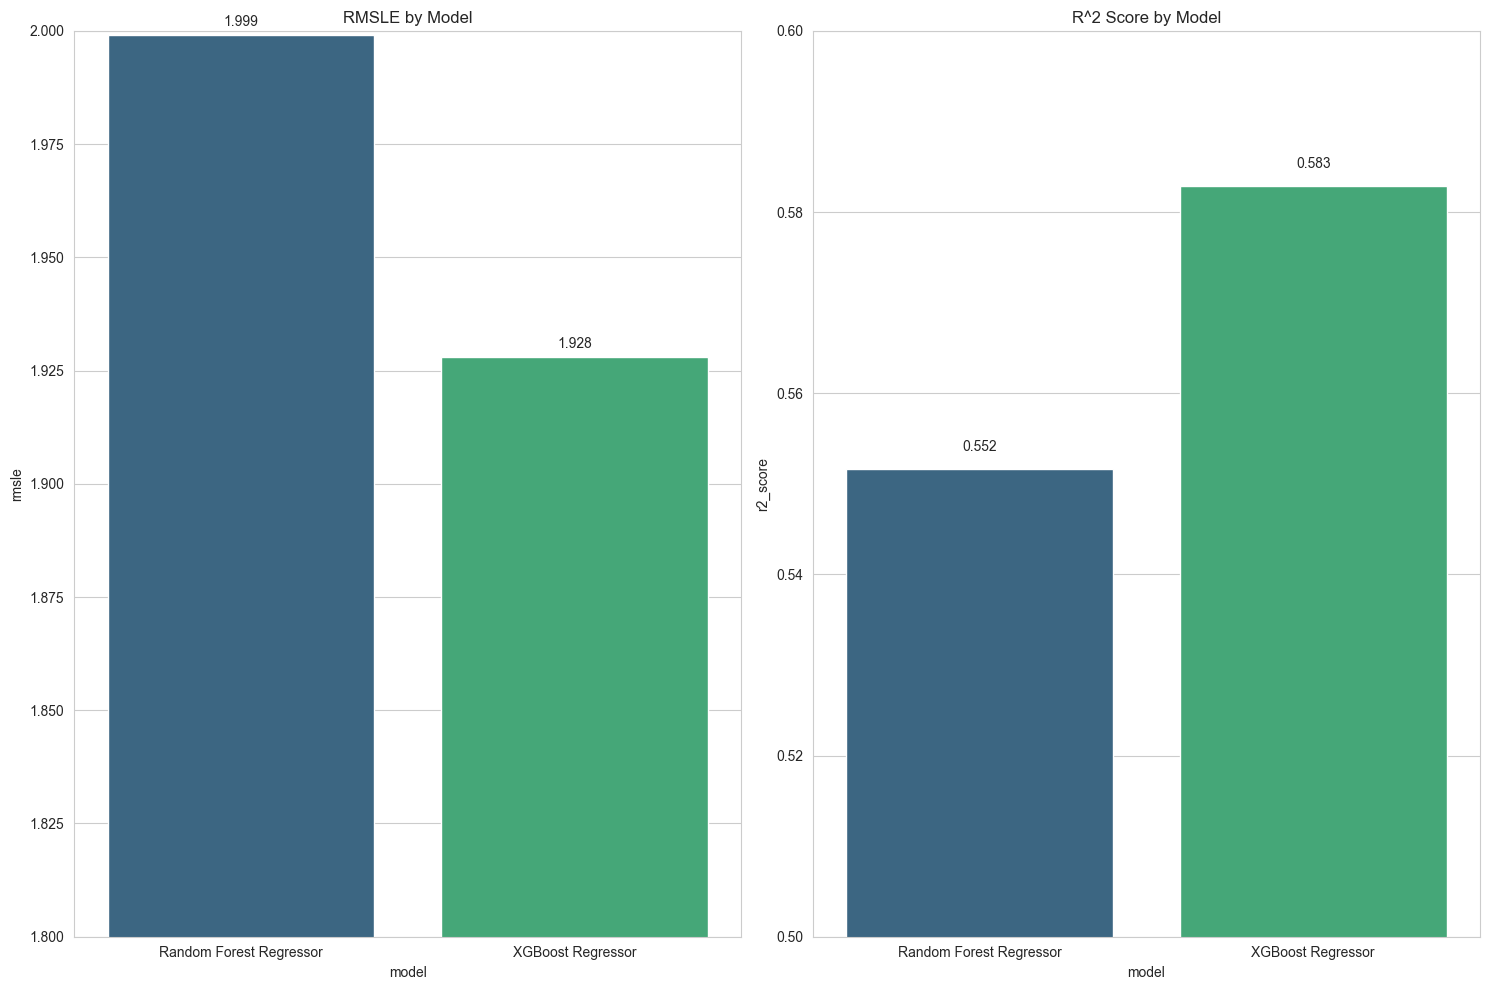

In [44]:
results = pd.DataFrame(results)

plt.figure(figsize=(15, 10))

plt.subplot(1, 2, 1)
sns.barplot(x='model', y='rmsle', data=results, palette='viridis', hue='model', legend=False)
plt.title('RMSLE by Model')
plt.ylim(1.8, 2)
for i, v in enumerate(results["rmsle"]):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.subplot(1, 2, 2)
sns.barplot(x='model', y='r2_score', data=results, palette='viridis', hue='model', legend=False)
plt.title('R^2 Score by Model')
plt.ylim(.5, .6)
for i, v in enumerate(results["r2_score"]):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

## 5. Prediction and Submission

In [45]:
y_pred = xgb_best.predict(X_test)

submission = pd.DataFrame({
    'id': X_test.index,
    'revenue': np.expm1(y_pred)
})

submission.to_csv('../data/submission.csv', index=False)